In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    learning_curve,
    StratifiedKFold
)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

import xgboost as xgb
import warnings

warnings.filterwarnings("ignore")

In [3]:
# Set style for better visualizations 
plt.style.use('seaborn-v0_8-darkgrid') 
sns.set_palette("husl")

In [5]:
print("CUSTOMER CHURN PREDICTION MODEL COMPARISON") 


CUSTOMER CHURN PREDICTION MODEL COMPARISON


# ============================================
 1. LOAD AND EXPLORE DATASET 
# ============================================ 

In [6]:
print("\n Step 1: Loading Dataset...") 


 Step 1: Loading Dataset...


In [62]:
df = pd.read_csv("E:\ML Project\CUSTOMER CHURN PREDICTION\dataset\Telco-Customer-Churn - Telco-Customer-Churn.csv")

Data Analysis

In [10]:
df.shape

(7043, 21)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
df.isnull().sum().sum()

np.int64(11)

11 missing values total

In [16]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [18]:
print(f"  - Duplicate rows: {df.duplicated().sum()}")
print(f"  - Churn rate: {(df['Churn'] == 'Yes').mean() * 100:.2f}%") 

  - Duplicate rows: 0
  - Churn rate: 26.54%


 Create visualizations

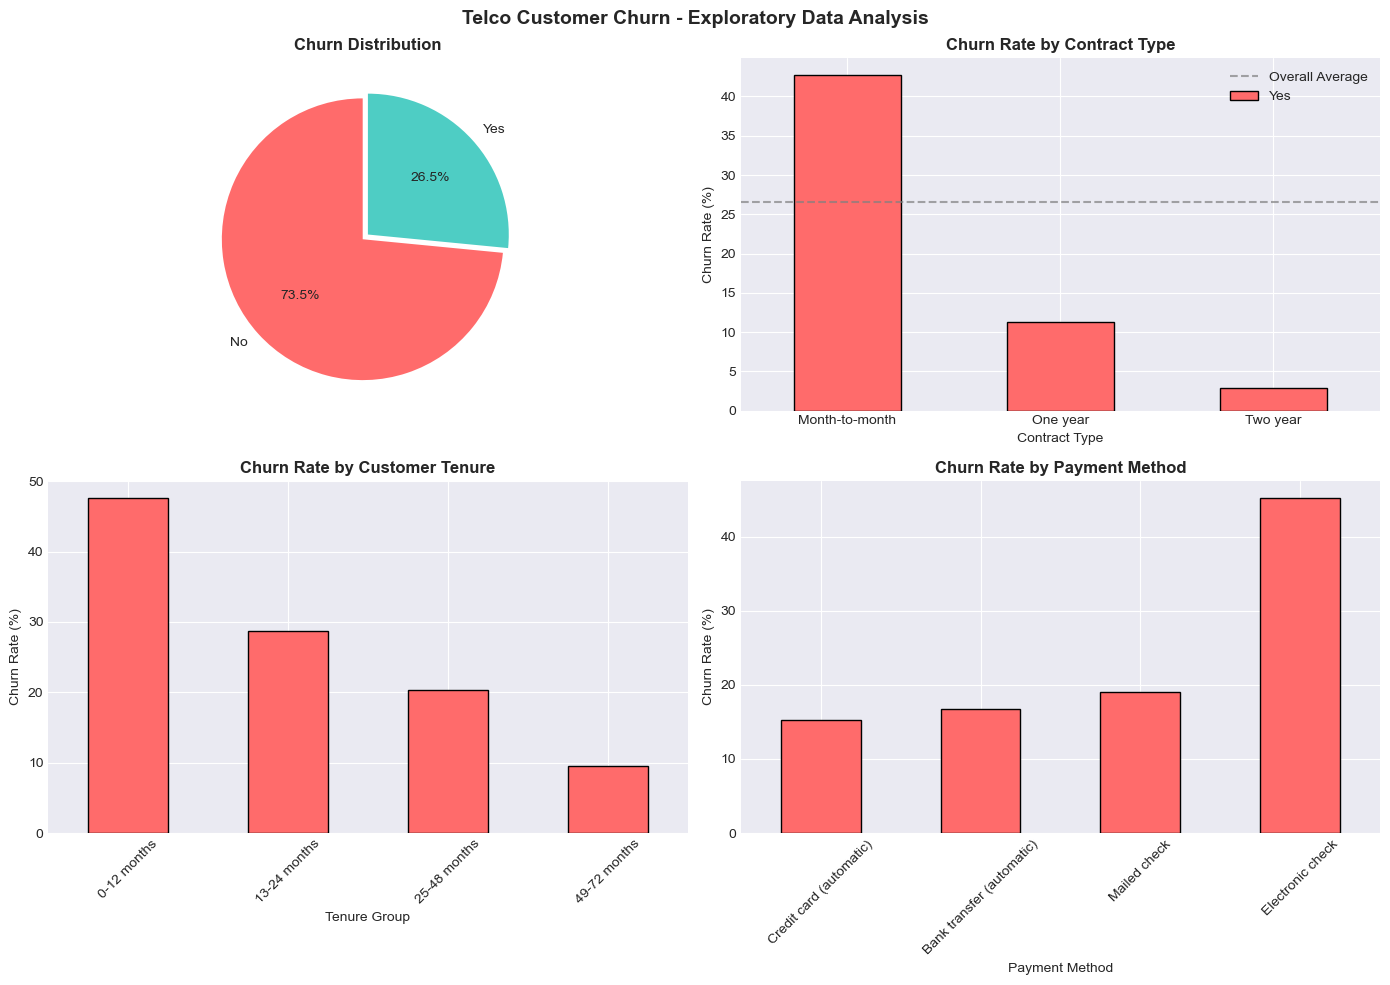

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Telco Customer Churn - Exploratory Data Analysis',
    fontsize=14,
    fontweight='bold'
)

# 1. Churn Distribution
churn_counts = df['Churn'].value_counts()

axes[0, 0].pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=['#ff6b6b', '#4ecdc4'],
    explode=[0.05, 0],
    startangle=90
)

axes[0, 0].set_title('Churn Distribution', fontweight='bold')

# 2. Churn by Contract Type
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn['Yes'].plot(
    kind='bar',
    ax=axes[0, 1],
    color='#ff6b6b',
    edgecolor='black'
)

axes[0, 1].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_xlabel('Contract Type')

axes[0, 1].axhline(
    y=(df['Churn'] == 'Yes').mean() * 100,
    color='gray',
    linestyle='--',
    label='Overall Average',
    alpha=0.7
)

axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=0)

# 3. Churn by Tenure
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=[
        '0-12 months',
        '13-24 months',
        '25-48 months',
        '49-72 months'
    ]
)

tenure_churn = pd.crosstab(
    df['tenure_group'],
    df['Churn'],
    normalize='index'
) * 100

tenure_churn['Yes'].plot(
    kind='bar',
    ax=axes[1, 0],
    color='#ff6b6b',
    edgecolor='black'
)

axes[1, 0].set_title('Churn Rate by Customer Tenure', fontweight='bold')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].set_xlabel('Tenure Group')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Churn by Payment Method
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn['Yes'].sort_values().plot(
    kind='bar',
    ax=axes[1, 1],
    color='#ff6b6b',
    edgecolor='black'
)

axes[1, 1].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[1, 1].set_ylabel('Churn Rate (%)')
axes[1, 1].set_xlabel('Payment Method')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The pie chart shows that most customers did not churn, while a smaller percentage left the company. This indicates that customer retention is higher than customer loss, although churn still represents a considerable portion of the customer base.

Customers with month-to-month contracts have the highest churn rate, while those with one-year or two-year contracts have much lower churn rates. This suggests that longer contracts are associated with better customer retention.

Customers who have been with the company for less than one year have the highest churn rate. The churn rate decreases as customer tenure increases, indicating that long-term customers are less likely to leave.

Customers using electronic checks have the highest churn rate, whereas customers using automatic bank transfers or credit card payments have lower churn rates. This suggests that payment method may be related to customer retention.


# ============================================ 
# 3. DATA PREPROCESSING 
# ============================================ 

In [27]:
# Create a clean copy for modeling 
df = df.copy() 
# Drop customerID (not useful for prediction) 
if 'customerID' in df.columns: 
    df = df.drop('customerID', axis=1) 


In [28]:
# Remove temporary tenure_group column if it exists 
if 'tenure_group' in df.columns: 
    df = df.drop('tenure_group', axis=1) 

In [29]:
# Convert TotalCharges to numeric (it might be string with empty spaces) 
if 'TotalCharges' in df.columns: 
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], 
errors='coerce')

In [30]:
# Fill missing TotalCharges with MonthlyCharges (reasonable assumption) 
df['TotalCharges'].fillna(df['MonthlyCharges'], 
inplace=True)

In [31]:
# Separate features and target 
X = df.drop('Churn', axis=1) 
y = df['Churn'].map({'Yes': 1, 'No': 0})

In [32]:
# Identify column types 
categorical_cols = X.select_dtypes(include=['object']).columns.tolist() 
numerical_cols = X.select_dtypes(include=['int64', 
'float64']).columns.tolist() 

In [33]:
print(f"\n  - Numerical features ({len(numerical_cols)}): {numerical_cols}") 
print(f"  - Categorical features ({len(categorical_cols)}): {categorical_cols}")


  - Numerical features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
  - Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [34]:
# Encode categorical variables 
print("\n  Encoding categorical variables...") 
label_encoders = {} 
for col in categorical_cols: 
    le = LabelEncoder() 
    X[col] = le.fit_transform(X[col].astype(str)) 
    label_encoders[col] = le 
    print(f" ✓ {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}") 


  Encoding categorical variables...
 ✓ gender: {'Female': np.int64(0), 'Male': np.int64(1)}
 ✓ Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
 ✓ Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
 ✓ PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
 ✓ MultipleLines: {'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
 ✓ InternetService: {'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
 ✓ OnlineSecurity: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
 ✓ OnlineBackup: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
 ✓ DeviceProtection: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
 ✓ TechSupport: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
 ✓ StreamingTV: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
 ✓ StreamingMovies: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}

In [35]:
# Scale numerical features 
print("\n  Scaling numerical features...") 
scaler = StandardScaler() 
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])


  Scaling numerical features...


In [36]:
# Verify all data is numeric 
print("\n Data validation:") 
print(f"    - All features numeric: {all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns)}") 
print(f"    - Missing values: {X.isnull().sum().sum()}") 
print(f"    - Data types: {X.dtypes.unique()}")


 Data validation:
    - All features numeric: True
    - Missing values: 0
    - Data types: [dtype('int64') dtype('float64')]


In [37]:
# Train-test split 
X_train, X_test, y_train, y_test = train_test_split( 
X, y, test_size=0.2, random_state=42, stratify=y 
) 
print(f"\n  Training set: {X_train.shape[0]} samples") 
print(f"  Test set: {X_test.shape[0]} samples") 
print(f"  Class distribution (training):") 
print(f" Step 3: Data Preprocessing... - No Churn: {(y_train == 0).sum()} ({(y_train == 
0).mean()*100:.1f}%)") 
print(f"    - Churn: {(y_train == 1).sum()} ({(y_train == 
1).mean()*100:.1f}%)")


  Training set: 5634 samples
  Test set: 1409 samples
  Class distribution (training):
 Step 3: Data Preprocessing... - No Churn: 4139 (73.5%)
    - Churn: 1495 (26.5%)


# ============================================ 
# 4. MODEL TRAINING 
# ============================================

In [ ]:
print("\nStep 4: Training Models...")

models = {
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        min_samples_split=20
    ),

    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=10,
        min_samples_split=20,
        n_jobs=1
    ),

    'XGBoost': xgb.XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='logloss'
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1
    )
}


results = {}
trained_models = {}

for name, model in models.items():

    print(f"\n  Training {name}...")

    try:

        # Train the model
        model.fit(X_train, y_train)

        trained_models[name] = model

        # Make predictions
        y_pred = model.predict(X_test)

        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate evaluation metrics
        results[name] = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
        }

        print(f"    ✓ Accuracy: {results[name]['Accuracy']:.4f}")
        print(f"    ✓ ROC-AUC: {results[name]['ROC-AUC']:.4f}")

    except Exception as e:

        print(f"✗ Error: {str(e)}")

        results[name] = {
            'Accuracy': 0,
            'Precision': 0,
            'Recall': 0,
            'F1-Score': 0,
            'ROC-AUC': 0
        }


Step 4: Training Models...

  Training Decision Tree...
    ✓ Accuracy: 0.7807
    ✓ ROC-AUC: 0.7892

  Training Random Forest...
    ✓ Accuracy: 0.8006
    ✓ ROC-AUC: 0.8413

  Training XGBoost...
    ✓ Accuracy: 0.7935
    ✓ ROC-AUC: 0.8352

  Training Gradient Boosting...
    ✓ Accuracy: 0.7956
    ✓ ROC-AUC: 0.8358


# ============================================ 
# 5. RESULTS & VISUALIZATIONS 
# ============================================ 

In [51]:
print("\n Step 5: Generating Visualizations...") 
 
# Create results dataframe 
results_df = pd.DataFrame(results).T
print(results_df)


 Step 5: Generating Visualizations...
                   Accuracy  Precision    Recall  F1-Score   ROC-AUC
Decision Tree      0.780696   0.588556  0.577540  0.582996  0.789222
Random Forest      0.800568   0.660900  0.510695  0.576169  0.841295
XGBoost            0.793471   0.636964  0.516043  0.570162  0.835192
Gradient Boosting  0.795600   0.645270  0.510695  0.570149  0.835831


Interpretation

A higher bar means better performance

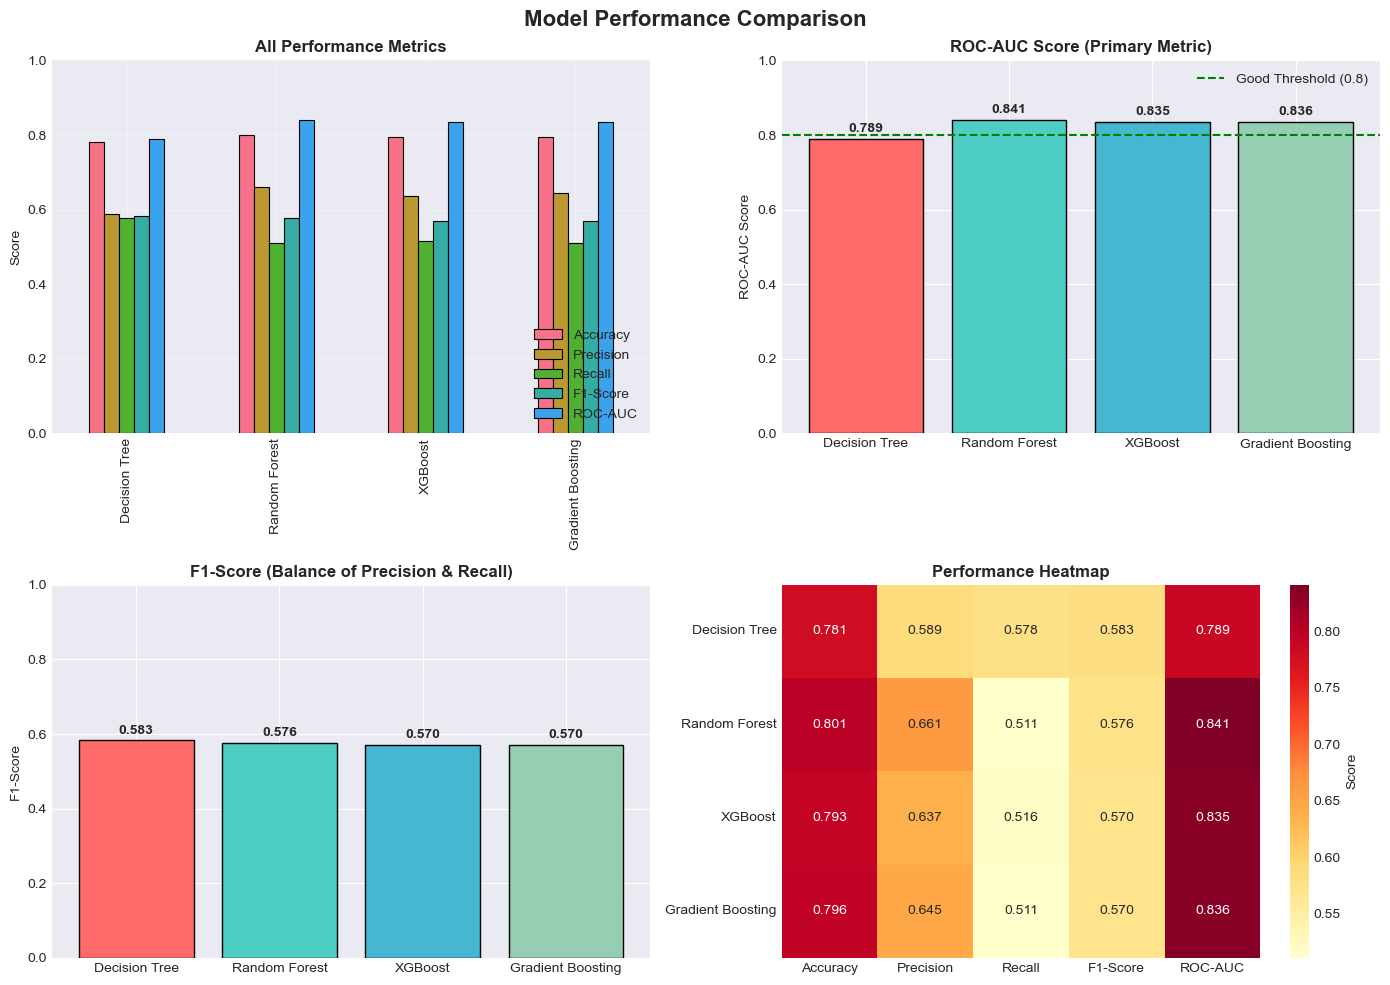

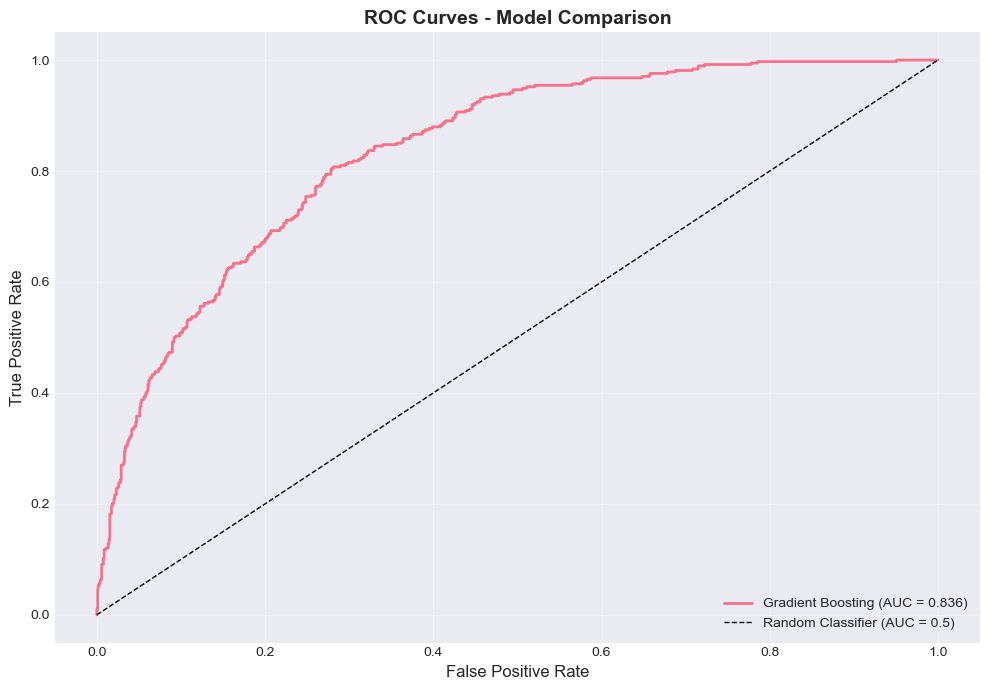

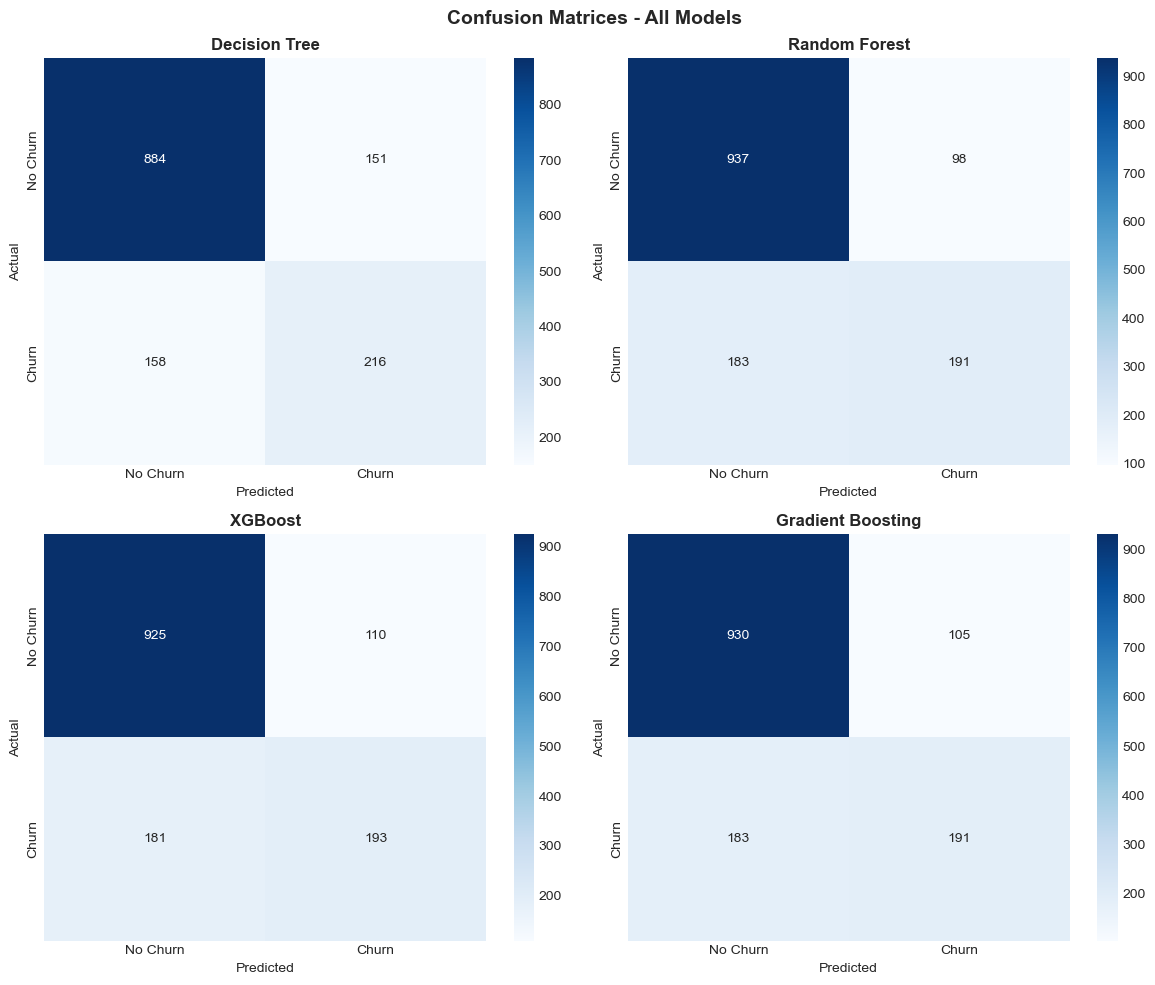


Generating Learning Curves...


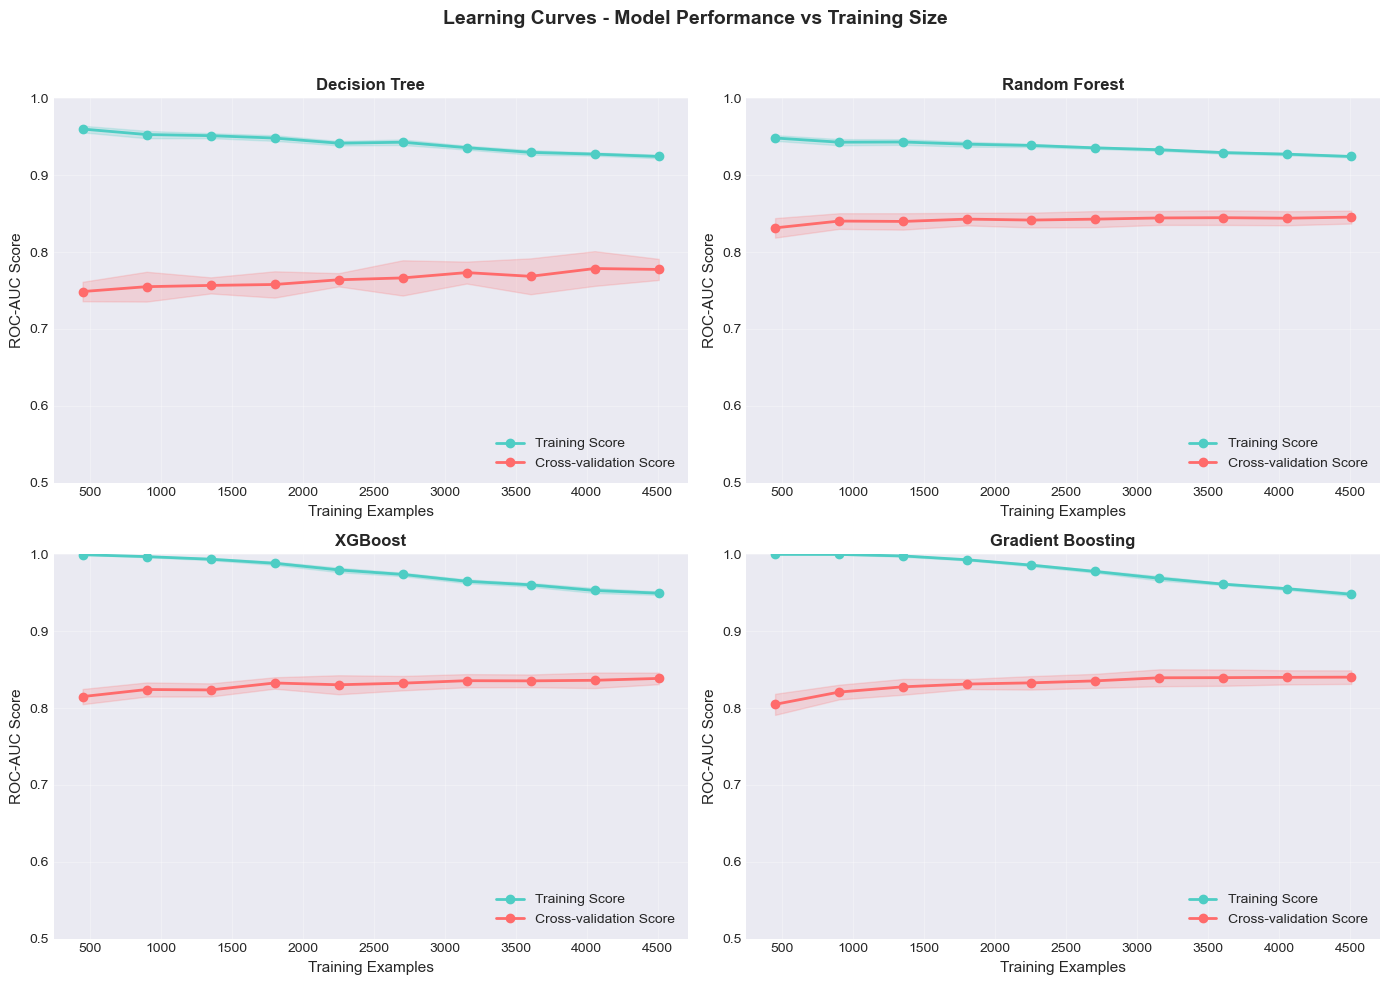


Feature Importance Analysis - Random Forest


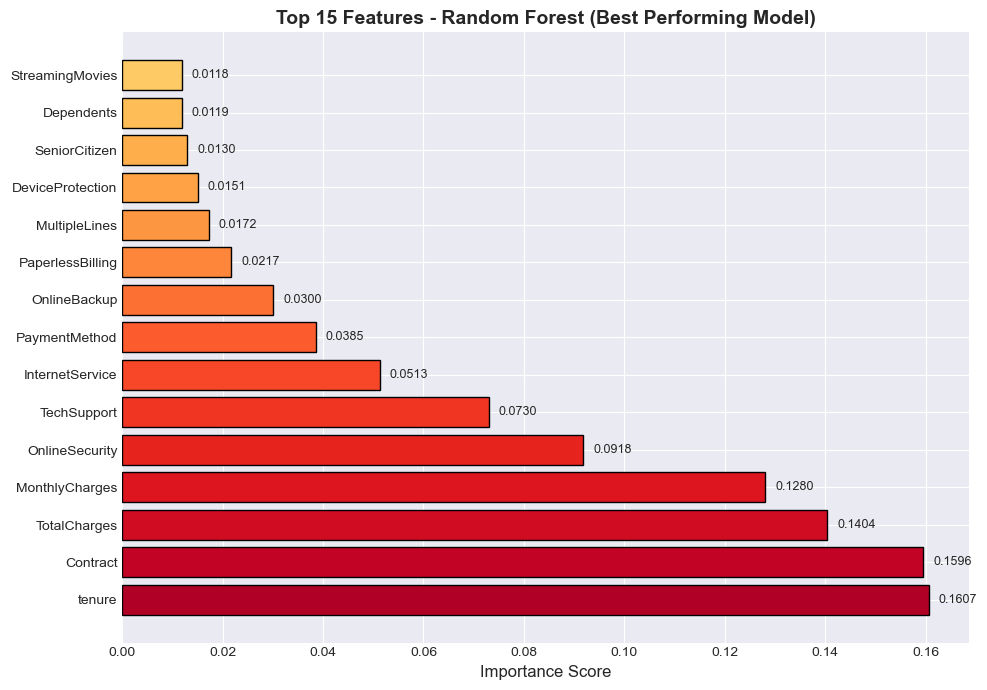

In [55]:
# Figure 1: Performance Comparison 
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) 
fig.suptitle('Model Performance Comparison', fontsize=16, 
fontweight='bold')

# Bar plot - all metrics 
results_df.plot(kind='bar', ax=axes[0, 0], edgecolor='black', 
linewidth=0.8) 
axes[0, 0].set_title('All Performance Metrics', fontweight='bold') 
axes[0, 0].set_ylabel('Score') 
axes[0, 0].set_ylim([0, 1]) 
axes[0, 0].legend(loc='lower right') 
axes[0, 0].grid(True, alpha=0.3)

 
# ROC-AUC comparison 
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']
bars = axes[0, 1].bar(results_df.index, results_df['ROC-AUC'], 
color=colors[:len(results_df)], edgecolor='black') 
axes[0, 1].set_title('ROC-AUC Score (Primary Metric)', fontweight='bold') 
axes[0, 1].set_ylabel('ROC-AUC Score') 
axes[0, 1].set_ylim([0, 1]) 
axes[0, 1].axhline(y=0.8, color='green', linestyle='--', label='Good Threshold (0.8)') 
axes[0, 1].legend() 
for bar, score in zip(bars, results_df['ROC-AUC']): 
    if score > 0: 
     axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 
0.01, 
f'{score:.3f}', ha='center', va='bottom', fontweight='bold') 

# F1-Score comparison 
bars = axes[1, 0].bar(results_df.index, results_df['F1-Score'], 
color=colors[:len(results_df)], edgecolor='black') 
axes[1, 0].set_title('F1-Score (Balance of Precision & Recall)', 
fontweight='bold') 
axes[1, 0].set_ylabel('F1-Score') 
axes[1, 0].set_ylim([0, 1]) 
for bar, score in zip(bars, results_df['F1-Score']): 
    if score > 0: 
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 
0.01, 
f'{score:.3f}', ha='center', va='bottom', 
fontweight='bold') 

# Heatmap 
sns.heatmap(results_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1, 
1], cbar_kws={'label': 'Score'}) 
axes[1, 1].set_title('Performance Heatmap', fontweight='bold') 
plt.tight_layout() 
plt.show() 

# Figure 2: ROC Curves 
plt.figure(figsize=(10, 7)) 
for name, model in trained_models.items(): 
    y_pred_proba = model.predict_proba(X_test)[:, 1] 
fpr, tpr, _ = roc_curve(y_test, y_pred_proba) 
auc = results[name]['ROC-AUC'] 
plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})') 
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)') 
plt.xlabel('False Positive Rate', fontsize=12) 
plt.ylabel('True Positive Rate', fontsize=12) 
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold') 
plt.legend(loc='lower right') 
plt.grid(True, alpha=0.3) 
plt.tight_layout() 
plt.show()

# Figure 3: Confusion Matrices 
fig, axes = plt.subplots(2, 2, figsize=(12, 10)) 
fig.suptitle('Confusion Matrices - All Models', fontsize=14, 
fontweight='bold') 
for idx, (name, model) in enumerate(trained_models.items()):
   if idx < 4: 
        y_pred = model.predict(X_test) 
        cm = confusion_matrix(y_test, y_pred) 
        row, col = divmod(idx, 2) 
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, 
col], 
        xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn']) 
        axes[row, col].set_title(name, fontweight='bold') 
        axes[row, col].set_xlabel('Predicted') 
        axes[row, col].set_ylabel('Actual') 
plt.tight_layout() 
plt.show()

# Figure 4: Learning Curves

print("\nGenerating Learning Curves...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Learning Curves - Model Performance vs Training Size',
    fontsize=14,
    fontweight='bold'
)

for idx, (name, model) in enumerate(trained_models.items()):
    if idx < 4:
        row, col = divmod(idx, 2)

        try:
            train_sizes, train_scores, test_scores = learning_curve(
                model,
                X_train,
                y_train,
                cv=StratifiedKFold(
                    n_splits=5,
                    shuffle=True,
                    random_state=42
                ),
                train_sizes=np.linspace(0.1, 1.0, 10),
                scoring='roc_auc',
                n_jobs=-1
            )

            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            test_mean = np.mean(test_scores, axis=1)
            test_std = np.std(test_scores, axis=1)

            # Training score
            axes[row, col].plot(
                train_sizes,
                train_mean,
                'o-',
                color='#4ecdc4',
                linewidth=2,
                label='Training Score'
            )
            axes[row, col].fill_between(
                train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.2,
                color='#4ecdc4'
            )

            # Cross-validation score
            axes[row, col].plot(
                train_sizes,
                test_mean,
                'o-',
                color='#ff6b6b',
                linewidth=2,
                label='Cross-validation Score'
            )
            axes[row, col].fill_between(
                train_sizes,
                test_mean - test_std,
                test_mean + test_std,
                alpha=0.2,
                color='#ff6b6b'
            )

            axes[row, col].set_xlabel('Training Examples', fontsize=11)
            axes[row, col].set_ylabel('ROC-AUC Score', fontsize=11)
            axes[row, col].set_title(name, fontweight='bold')
            axes[row, col].legend(loc='lower right')
            axes[row, col].grid(True, alpha=0.3)
            axes[row, col].set_ylim([0.5, 1.0])

        except Exception as e:
            axes[row, col].text(
                0.5,
                0.5,
                f"Could not generate\nlearning curve\n{str(e)[:50]}",
                ha='center',
                va='center',
                transform=axes[row, col].transAxes
            )
            axes[row, col].set_title(name)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Figure 5: Feature Importance (for best model)

best_model_name = max(
    results,
    key=lambda x: results[x]['ROC-AUC'] if results[x]['ROC-AUC'] > 0 else -1
)

best_model = trained_models.get(best_model_name)

if best_model and hasattr(best_model, 'feature_importances_'):
    print(f"\nFeature Importance Analysis - {best_model_name}")

    importances = best_model.feature_importances_
    indices = np.argsort(importances)[-15:]

    plt.figure(figsize=(10, 7))

    colors_bar = plt.cm.YlOrRd(np.linspace(0.3, 0.9, 15))
    bars = plt.barh(
        range(15),
        importances[indices],
        color=colors_bar,
        edgecolor='black'
    )

    plt.yticks(range(15), [X.columns[i] for i in indices])
    plt.xlabel('Importance Score', fontsize=12)
    plt.title(
        f'Top 15 Features - {best_model_name} (Best Performing Model)',
        fontsize=14,
        fontweight='bold'
    )

    plt.gca().invert_yaxis()

    # Add value labels
    for bar, val in zip(bars, importances[indices]):
        plt.text(
            val + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}',
            va='center',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()



# ============================================ 
# 6. FINAL SUMMARY 
# ============================================

In [56]:
print("\n" + "=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

print(
    f"\n{'Model':<20} {'ROC-AUC':<12} {'F1-Score':<12} "
    f"{'Accuracy':<12} {'Precision':<12} {'Recall':<12}"
)

print("-" * 80)

for name, metrics in results.items():
    print(
        f"{name:<20} "
        f"{metrics['ROC-AUC']:<12.4f} "
        f"{metrics['F1-Score']:<12.4f} "
        f"{metrics['Accuracy']:<12.4f} "
        f"{metrics['Precision']:<12.4f} "
        f"{metrics['Recall']:<12.4f}"
    )

print("\n" + "=" * 60)
print("RECOMMENDATIONS & INSIGHTS")
print("=" * 60)


FINAL RESULTS SUMMARY

Model                ROC-AUC      F1-Score     Accuracy     Precision    Recall      
--------------------------------------------------------------------------------
Decision Tree        0.7892       0.5830       0.7807       0.5886       0.5775      
Random Forest        0.8413       0.5762       0.8006       0.6609       0.5107      
XGBoost              0.8352       0.5702       0.7935       0.6370       0.5160      
Gradient Boosting    0.8358       0.5701       0.7956       0.6453       0.5107      

RECOMMENDATIONS & INSIGHTS


In [57]:
# Find best model

best_model = max(results, key=lambda x: results[x]['ROC-AUC'])
best_score = results[best_model]['ROC-AUC']

print(f"\nBest Performing Model: {best_model}")
print(f"   • ROC-AUC Score: {best_score:.4f}")
print(f"   • F1-Score: {results[best_model]['F1-Score']:.4f}")
print(f"   • Accuracy: {results[best_model]['Accuracy']:.4f}")

print("\nKey Business Insights from Data:")
print("   • Customers with month-to-month contracts have the highest churn risk")
print("   • Churn is highest during the first 12 months of customer tenure")
print("   • Electronic check payment method correlates with higher churn")
print("   • Customers without additional services (tech support, online security) churn more")
print("   • Senior citizens show different churn patterns than younger customers")

print("\nActionable Recommendations:")
print("   • Offer incentives for longer-term contracts")
print("   • Implement early retention programs for new customers (first year)")
print("   • Promote paperless billing and automatic payment methods")
print("   • Bundle services to increase customer stickiness")
print("   • Create targeted offers for high-risk segments")


Best Performing Model: Random Forest
   • ROC-AUC Score: 0.8413
   • F1-Score: 0.5762
   • Accuracy: 0.8006

Key Business Insights from Data:
   • Customers with month-to-month contracts have the highest churn risk
   • Churn is highest during the first 12 months of customer tenure
   • Electronic check payment method correlates with higher churn
   • Customers without additional services (tech support, online security) churn more
   • Senior citizens show different churn patterns than younger customers

Actionable Recommendations:
   • Offer incentives for longer-term contracts
   • Implement early retention programs for new customers (first year)
   • Promote paperless billing and automatic payment methods
   • Bundle services to increase customer stickiness
   • Create targeted offers for high-risk segments
